# Paper-style β-VAE adapted to PROPHESY C1s spectra

This notebook implements the fully connected β-VAE described in *Unsupervised real-world knowledge extraction via disentangled variational autoencoders for photon diagnostics*, adapted to the PROPHESY-generated Excel files.

The paper used `14000 → 2824 → 579 → 117 → 24 → 12`, where the 24 encoder outputs represent 12 means and 12 log-variances. PROPHESY C1s spectra contain 401 points, so the corresponding network used here is `401 → 256 → 128 → 64 → 24 → 12`, with the mirrored decoder `12 → 64 → 128 → 256 → 401`. The latent dimension, Mish activations, sigmoid output, Adam optimizer, MSE reconstruction term, and β-weighted KL term follow the paper.

Peak parameters are **not used for training**. They are retained only to test whether physical properties emerge in the latent space, matching the paper's unsupervised analysis.

## Requirements

Use a Python environment containing PyTorch, NumPy, OpenPyXL, and Matplotlib. If necessary, install them in the active notebook kernel with:

```python
%pip install torch numpy openpyxl matplotlib
```

The cell is shown as documentation rather than executed automatically so the notebook does not modify your environment without permission.

In [1]:
from pathlib import Path
import copy
import json
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
from openpyxl import load_workbook
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__}; device={DEVICE}")

PyTorch 2.6.0; device=cpu


In [2]:
# Paths work when Jupyter is started in spectraVAE. The absolute fallback matches
# the current shared workspace and can be changed if the projects are moved.
prophesy_candidates = [
    (Path.cwd() / "../PROPHESY").resolve(),
    Path("/home/umar/projects/Thesis/PROPHESY"),
]
PROPHESY_ROOT = next((p for p in prophesy_candidates if (p / "data").exists()), None)
if PROPHESY_ROOT is None:
    raise FileNotFoundError("Set PROPHESY_ROOT to the PROPHESY project directory.")

DATA_ROOT = PROPHESY_ROOT / "data"
CACHE_DIR = Path.cwd() / "data_cache"
OUTPUT_DIR = Path.cwd() / "outputs" / "prophesy_beta_vae"
CACHE_FILE = CACHE_DIR / "prophesy_c1s_401.npz"
CHECKPOINT_FILE = OUTPUT_DIR / "best_beta_vae.pt"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_LENGTH = 401
REBUILD_CACHE = False
print(f"PROPHESY data: {DATA_ROOT}")
print(f"Cache: {CACHE_FILE}")

PROPHESY data: /home/umar/thesis/PROPHESY/data
Cache: /home/umar/thesis/Conditional_VAE/data_cache/prophesy_c1s_401.npz


## Extract compatible PROPHESY spectra

Each `Snoisy` or `Snoisy_*` column becomes one sample. The extractor keeps only non-water, non-S2p C1s sheets with 401 binding-energy points and a common energy axis. It also stores the simulated clean signal, background, expected total signal, photon energy, and three true peak components.

The workbook's parent directory becomes `case_id`. All spectra from the same case will remain in one train/validation/test partition, preventing repeated noise realizations of the same physical spectrum from leaking between partitions.

In [3]:
def _column(headers, name):
    return headers.index(name) if name in headers else None


def extract_prophesy_c1s(data_root: Path, target_length: int = 401):
    noisy_parts, clean_parts, background_parts, total_parts = [], [], [], []
    centers_parts, widths_parts, fractions_parts = [], [], []
    photon_energy_parts, case_parts, source_parts, sweep_parts = [], [], [], []
    reference_axis = None
    skipped_axis = 0
    skipped_incomplete = 0

    workbook_paths = sorted(data_root.rglob("data.xlsx"))
    for workbook_path in workbook_paths:
        # Start with one chemically consistent family and one fixed grid.
        if "S2p" in workbook_path.parts or "water" in workbook_path.parts:
            continue

        case_id = str(workbook_path.parent.relative_to(data_root))
        workbook = load_workbook(workbook_path, read_only=True, data_only=True)
        sheet_names = set(workbook.sheetnames)

        for sheet_name in workbook.sheetnames:
            if not sheet_name.startswith("hν_"):
                continue
            ws = workbook[sheet_name]
            if ws.max_row - 1 != target_length:
                continue

            headers = [cell.value for cell in next(ws.iter_rows(min_row=1, max_row=1))]
            required = {"Be", "Snoisy", "SpectrumA_1", "Sbg", "Stot", "hν"}
            if not required.issubset(set(headers)):
                skipped_incomplete += 1
                continue

            rows = list(ws.iter_rows(min_row=2, values_only=True))
            block = np.asarray(rows, dtype=np.float64)
            axis = block[:, _column(headers, "Be")].astype(np.float32)
            if reference_axis is None:
                reference_axis = axis
            elif not np.allclose(axis, reference_axis, rtol=0.0, atol=1e-6):
                skipped_axis += 1
                continue

            noise_indices = [
                i for i, name in enumerate(headers)
                if name == "Snoisy" or (isinstance(name, str) and name.startswith("Snoisy_"))
            ]
            if not noise_indices:
                continue

            noisy = block[:, noise_indices].T.astype(np.float32)
            n_samples = noisy.shape[0]
            clean = block[:, _column(headers, "SpectrumA_1")].astype(np.float32)
            background = block[:, _column(headers, "Sbg")].astype(np.float32)
            expected_total = block[:, _column(headers, "Stot")].astype(np.float32)
            photon_energy = float(block[0, _column(headers, "hν")])

            meta_name = f"meta_{sheet_name}"
            if meta_name not in sheet_names:
                skipped_incomplete += 1
                continue
            meta_ws = workbook[meta_name]
            meta_headers = [cell.value for cell in next(meta_ws.iter_rows(min_row=1, max_row=1))]
            meta_rows = np.asarray(
                list(meta_ws.iter_rows(min_row=2, values_only=True)), dtype=np.float64
            )
            if meta_rows.ndim != 2 or meta_rows.shape[0] < 3:
                skipped_incomplete += 1
                continue
            centers = meta_rows[:3, _column(meta_headers, "peak_mode")].astype(np.float32)
            widths = meta_rows[:3, _column(meta_headers, "peak_width")].astype(np.float32)
            fractions = meta_rows[:3, _column(meta_headers, "peak_probability")].astype(np.float32)

            noisy_parts.append(noisy)
            clean_parts.append(np.repeat(clean[None, :], n_samples, axis=0))
            background_parts.append(np.repeat(background[None, :], n_samples, axis=0))
            total_parts.append(np.repeat(expected_total[None, :], n_samples, axis=0))
            centers_parts.append(np.repeat(centers[None, :], n_samples, axis=0))
            widths_parts.append(np.repeat(widths[None, :], n_samples, axis=0))
            fractions_parts.append(np.repeat(fractions[None, :], n_samples, axis=0))
            photon_energy_parts.append(np.full(n_samples, photon_energy, dtype=np.float32))
            case_parts.extend([case_id] * n_samples)
            source_parts.extend([f"{workbook_path.relative_to(data_root)}::{sheet_name}"] * n_samples)
            sweep_parts.extend([str(headers[i]) for i in noise_indices])

        workbook.close()

    if not noisy_parts:
        raise RuntimeError("No compatible 401-point C1s spectra were found.")

    result = {
        "axis": reference_axis,
        "noisy": np.concatenate(noisy_parts),
        "clean": np.concatenate(clean_parts),
        "background": np.concatenate(background_parts),
        "expected_total": np.concatenate(total_parts),
        "peak_center": np.concatenate(centers_parts),
        "peak_width": np.concatenate(widths_parts),
        "peak_fraction": np.concatenate(fractions_parts),
        "photon_energy": np.concatenate(photon_energy_parts),
        "case_id": np.asarray(case_parts),
        "source": np.asarray(source_parts),
        "sweep": np.asarray(sweep_parts),
    }
    print(f"Skipped {skipped_axis} sheets with a different axis.")
    print(f"Skipped {skipped_incomplete} incomplete sheets.")
    return result

In [4]:
if REBUILD_CACHE or not CACHE_FILE.exists():
    dataset = extract_prophesy_c1s(DATA_ROOT, TARGET_LENGTH)
    np.savez_compressed(CACHE_FILE, **dataset)
    print(f"Saved {CACHE_FILE}")
else:
    with np.load(CACHE_FILE, allow_pickle=False) as cached:
        dataset = {name: cached[name] for name in cached.files}
    print(f"Loaded {CACHE_FILE}")

print(f"Spectra: {dataset['noisy'].shape}")
print(f"Independent cases: {np.unique(dataset['case_id']).size}")
print(f"Photon-energy range: {dataset['photon_energy'].min():.1f}–{dataset['photon_energy'].max():.1f} eV")
print(f"Count range: {dataset['noisy'].min():.1f}–{dataset['noisy'].max():.1f}")

Skipped 0 sheets with a different axis.
Skipped 0 incomplete sheets.
Saved /home/umar/thesis/Conditional_VAE/data_cache/prophesy_c1s_401.npz
Spectra: (16640, 401)
Independent cases: 95
Photon-energy range: 650.0–1884.0 eV
Count range: 0.0–148100.0


## Leakage-safe split and normalization

Splitting is performed by physical case rather than spectrum. Repeated noisy acquisitions from one simulated condition therefore cannot appear in both training and testing.

PROPHESY stores non-negative electron counts with a much wider dynamic range than the paper's 8-bit ADC values. The notebook applies `log1p` followed by a training-only 99.9th-percentile scale and clipping to `[0, 1]`. This retains a sigmoid decoder while avoiding domination by the highest-count spectra.

In [5]:
all_cases = np.unique(dataset["case_id"])
rng = np.random.default_rng(SEED)
shuffled_cases = rng.permutation(all_cases)
n_cases = len(shuffled_cases)
n_test = max(1, int(round(0.15 * n_cases)))
n_val = max(1, int(round(0.15 * n_cases)))
test_cases = set(shuffled_cases[:n_test])
val_cases = set(shuffled_cases[n_test:n_test + n_val])
train_cases = set(shuffled_cases[n_test + n_val:])

case_ids = dataset["case_id"]
train_idx = np.flatnonzero(np.isin(case_ids, list(train_cases)))
val_idx = np.flatnonzero(np.isin(case_ids, list(val_cases)))
test_idx = np.flatnonzero(np.isin(case_ids, list(test_cases)))
assert train_cases.isdisjoint(val_cases | test_cases)
assert val_cases.isdisjoint(test_cases)

log_train = np.log1p(dataset["noisy"][train_idx])
LOG_SCALE = float(np.quantile(log_train, 0.999))
if not np.isfinite(LOG_SCALE) or LOG_SCALE <= 0:
    raise ValueError("Invalid normalization scale.")

def normalize_counts(x):
    return np.clip(np.log1p(np.maximum(x, 0.0)) / LOG_SCALE, 0.0, 1.0).astype(np.float32)

def denormalize_counts(x):
    return np.expm1(np.clip(x, 0.0, 1.0) * LOG_SCALE)

x_all = normalize_counts(dataset["noisy"])
x_expected_all = normalize_counts(dataset["expected_total"])

def make_loader(indices, shuffle):
    tensors = TensorDataset(torch.from_numpy(x_all[indices]))
    return DataLoader(
        tensors, batch_size=256, shuffle=shuffle, num_workers=0,
        pin_memory=torch.cuda.is_available(), drop_last=False,
    )

train_loader = make_loader(train_idx, True)
val_loader = make_loader(val_idx, False)
test_loader = make_loader(test_idx, False)
print(f"train={len(train_idx):,}, validation={len(val_idx):,}, test={len(test_idx):,}")
print(f"train cases={len(train_cases)}, validation cases={len(val_cases)}, test cases={len(test_cases)}")
print(f"log normalization scale={LOG_SCALE:.4f}")

train=10,705, validation=2,600, test=3,335
train cases=67, validation cases=14, test cases=14
log normalization scale=11.1926


## β-VAE architecture

The final encoder layer produces 24 values, split into twelve-dimensional `mu` and `logvar`. The decoder mirrors the encoder but excludes that distribution-parameter layer, as in the paper.

In [6]:
class BetaVAE(nn.Module):
    def __init__(self, input_dim=401, latent_dim=12):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256), nn.Mish(),
            nn.Linear(256, 128), nn.Mish(),
            nn.Linear(128, 64), nn.Mish(),
        )
        self.latent_statistics = nn.Linear(64, 2 * latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.Mish(),
            nn.Linear(64, 128), nn.Mish(),
            nn.Linear(128, 256), nn.Mish(),
            nn.Linear(256, input_dim), nn.Sigmoid(),
        )
        self.apply(self._initialize)

    @staticmethod
    def _initialize(module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            nn.init.zeros_(module.bias)

    def encode(self, x):
        statistics = self.latent_statistics(self.encoder(x))
        return statistics.chunk(2, dim=-1)

    @staticmethod
    def reparameterize(mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

model = BetaVAE(input_dim=TARGET_LENGTH, latent_dim=12).to(DEVICE)
print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

BetaVAE(
  (encoder): Sequential(
    (0): Linear(in_features=401, out_features=256, bias=True)
    (1): Mish()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): Mish()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): Mish()
  )
  (latent_statistics): Linear(in_features=64, out_features=24, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): Mish()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): Mish()
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): Mish()
    (6): Linear(in_features=256, out_features=401, bias=True)
    (7): Sigmoid()
  )
)
Trainable parameters: 290,857


## Training

The loss sums reconstruction error across spectral channels and KL divergence across latent dimensions, then averages across the batch. This makes the two terms' reductions explicit. The paper's `β = 0.034` is used as a starting value; it should still be tuned because the input dimensionality and noise statistics differ from FLASH.

In [7]:
BETA = 0.034
EPOCHS = 150
LEARNING_RATE_START = 1e-5
LEARNING_RATE_END = 1e-7
EARLY_STOPPING_PATIENCE = 25

def beta_vae_loss(reconstruction, x, mu, logvar, beta=BETA):
    reconstruction_loss = F.mse_loss(reconstruction, x, reduction="none").sum(dim=1).mean()
    kl_loss = (-0.5 * (1 + logvar - mu.square() - logvar.exp())).sum(dim=1).mean()
    return reconstruction_loss + beta * kl_loss, reconstruction_loss, kl_loss

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    sums = np.zeros(3, dtype=np.float64)
    count = 0
    for (x,) in loader:
        x = x.to(DEVICE, non_blocking=True)
        reconstruction, mu, logvar = model(x)
        values = beta_vae_loss(reconstruction, x, mu, logvar)
        batch_size = x.shape[0]
        sums += np.asarray([v.item() for v in values]) * batch_size
        count += batch_size
    return sums / count

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE_START)
gamma = (LEARNING_RATE_END / LEARNING_RATE_START) ** (1.0 / max(EPOCHS - 1, 1))
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)
history = {"train_total": [], "train_reconstruction": [], "train_kl": [],
           "val_total": [], "val_reconstruction": [], "val_kl": [], "lr": []}
best_val = math.inf
best_state = None
epochs_without_improvement = 0
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    sums = np.zeros(3, dtype=np.float64)
    count = 0
    for (x,) in train_loader:
        x = x.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        reconstruction, mu, logvar = model(x)
        loss, reconstruction_loss, kl_loss = beta_vae_loss(reconstruction, x, mu, logvar)
        loss.backward()
        optimizer.step()
        batch_size = x.shape[0]
        sums += np.asarray([loss.item(), reconstruction_loss.item(), kl_loss.item()]) * batch_size
        count += batch_size

    train_values = sums / count
    val_values = evaluate(model, val_loader)
    history["train_total"].append(train_values[0])
    history["train_reconstruction"].append(train_values[1])
    history["train_kl"].append(train_values[2])
    history["val_total"].append(val_values[0])
    history["val_reconstruction"].append(val_values[1])
    history["val_kl"].append(val_values[2])
    history["lr"].append(optimizer.param_groups[0]["lr"])

    if val_values[0] < best_val:
        best_val = float(val_values[0])
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
        torch.save({
            "model_state_dict": best_state,
            "input_dim": TARGET_LENGTH, "latent_dim": 12, "beta": BETA,
            "log_scale": LOG_SCALE, "seed": SEED,
            "train_cases": sorted(train_cases),
            "validation_cases": sorted(val_cases),
            "test_cases": sorted(test_cases),
        }, CHECKPOINT_FILE)
    else:
        epochs_without_improvement += 1

    scheduler.step()
    if epoch == 1 or epoch % 10 == 0:
        print(
            f"epoch {epoch:03d} | train={train_values[0]:.4f} "
            f"(rec={train_values[1]:.4f}, kl={train_values[2]:.4f}) | "
            f"val={val_values[0]:.4f} | lr={history['lr'][-1]:.2e}"
        )
    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

model.load_state_dict(best_state)
print(f"Best validation loss: {best_val:.4f}")
print(f"Training time: {(time.time() - start_time) / 60:.1f} minutes")
print(f"Checkpoint: {CHECKPOINT_FILE}")

epoch 001 | train=18.5647 (rec=18.5597, kl=0.1472) | val=17.5014 | lr=1.00e-05
epoch 010 | train=15.2562 (rec=14.8771, kl=11.1481) | val=14.1921 | lr=7.57e-06
epoch 020 | train=6.8576 (rec=6.0897, kl=22.5856) | val=6.2242 | lr=5.56e-06
epoch 030 | train=4.4553 (rec=3.7130, kl=21.8304) | val=4.0906 | lr=4.08e-06
epoch 040 | train=3.6781 (rec=2.9782, kl=20.5865) | val=3.3575 | lr=3.00e-06
epoch 050 | train=3.2546 (rec=2.5798, kl=19.8450) | val=3.0139 | lr=2.20e-06
epoch 060 | train=3.0363 (rec=2.3828, kl=19.2195) | val=2.8249 | lr=1.61e-06
epoch 070 | train=2.8873 (rec=2.2470, kl=18.8322) | val=2.6940 | lr=1.19e-06
epoch 080 | train=2.7834 (rec=2.1513, kl=18.5898) | val=2.6375 | lr=8.70e-07
epoch 090 | train=2.7206 (rec=2.0964, kl=18.3566) | val=2.5610 | lr=6.39e-07
epoch 100 | train=2.6381 (rec=2.0192, kl=18.2011) | val=2.5130 | lr=4.69e-07
epoch 110 | train=2.6256 (rec=2.0107, kl=18.0845) | val=2.4999 | lr=3.44e-07
epoch 120 | train=2.5786 (rec=1.9668, kl=17.9968) | val=2.4668 | lr=2.5

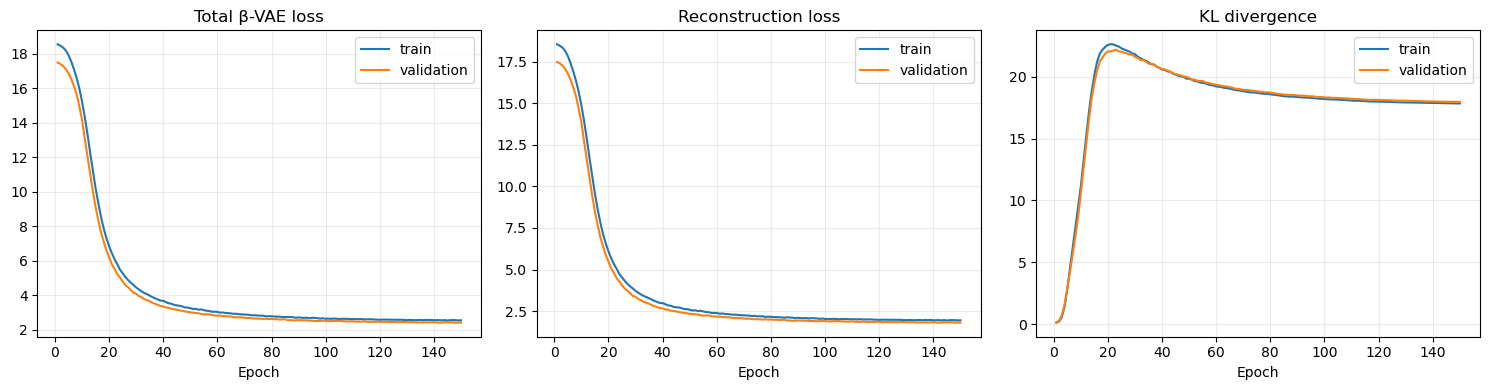

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = np.arange(1, len(history["train_total"]) + 1)
for ax, key, title in zip(
    axes, ["total", "reconstruction", "kl"],
    ["Total β-VAE loss", "Reconstruction loss", "KL divergence"],
):
    ax.plot(epochs, history[f"train_{key}"], label="train")
    ax.plot(epochs, history[f"val_{key}"], label="validation")
    ax.set(title=title, xlabel="Epoch")
    ax.grid(alpha=0.25)
    ax.legend()
plt.tight_layout()
plt.show()

## Reconstruction and denoising check

The grey line is a noisy simulated acquisition, black is the VAE reconstruction, and orange is PROPHESY's noise-free expected total signal. The VAE was trained only against the noisy input; the orange curve is used solely for evaluation.

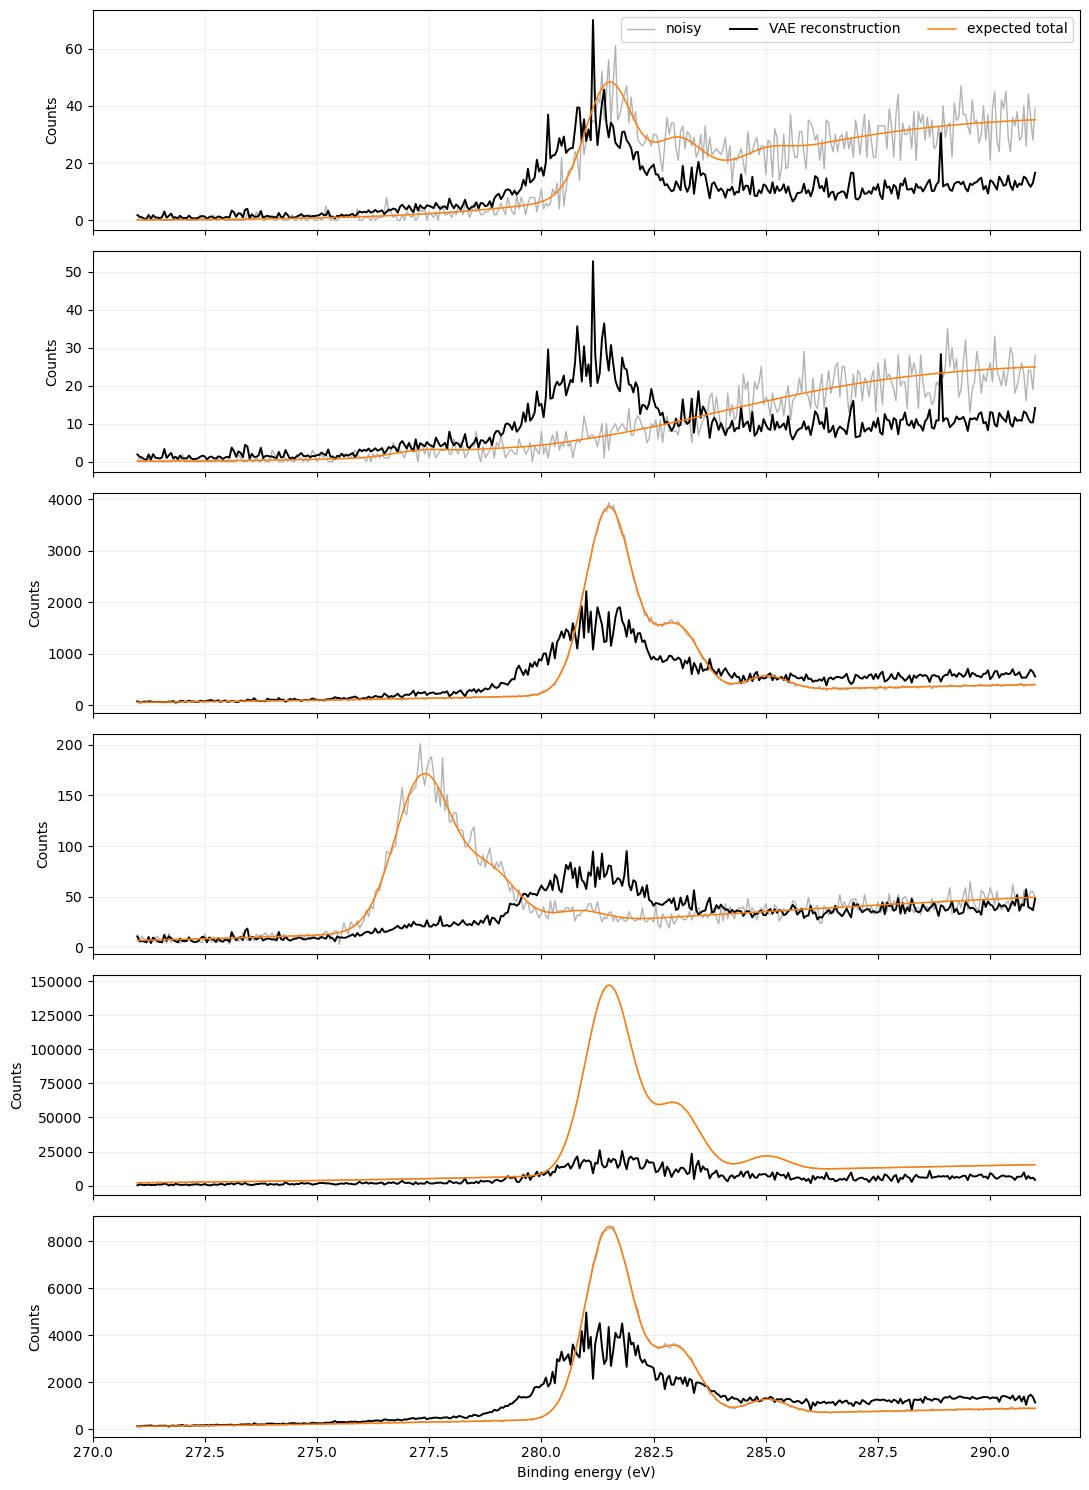

Test total=3.0191, reconstruction=2.3228, KL=20.4812
Normalized MSE to noisy input: 0.004806
Normalized MSE to expected total: 0.004314


In [9]:
model.eval()
plot_rng = np.random.default_rng(SEED + 1)
example_idx = plot_rng.choice(test_idx, size=min(6, len(test_idx)), replace=False)
with torch.no_grad():
    x = torch.from_numpy(x_all[example_idx]).to(DEVICE)
    mu, logvar = model.encode(x)
    reconstruction = model.decode(mu).cpu().numpy()  # deterministic reconstruction

raw_reconstruction = denormalize_counts(reconstruction)
axis = dataset["axis"]
fig, axes = plt.subplots(len(example_idx), 1, figsize=(11, 2.5 * len(example_idx)), sharex=True)
axes = np.atleast_1d(axes)
for ax, sample_index, reconstructed in zip(axes, example_idx, raw_reconstruction):
    ax.plot(axis, dataset["noisy"][sample_index], color="0.70", lw=1.0, label="noisy")
    ax.plot(axis, reconstructed, color="black", lw=1.4, label="VAE reconstruction")
    ax.plot(axis, dataset["expected_total"][sample_index], color="tab:orange", lw=1.1, label="expected total")
    ax.set_ylabel("Counts")
    ax.grid(alpha=0.2)
axes[0].legend(ncol=3)
axes[-1].set_xlabel("Binding energy (eV)")
plt.tight_layout()
plt.show()

test_values = evaluate(model, test_loader)
print(f"Test total={test_values[0]:.4f}, reconstruction={test_values[1]:.4f}, KL={test_values[2]:.4f}")
print(f"Normalized MSE to noisy input: {np.mean((reconstruction - x_all[example_idx]) ** 2):.6f}")
print(f"Normalized MSE to expected total: {np.mean((reconstruction - x_expected_all[example_idx]) ** 2):.6f}")

## Compare the latent space with known physical parameters

PROPHESY provides ground-truth peak centres, widths, and component fractions. The following heat map tests whether individual latent components recover those quantities without supervised peak labels.

/home/umar/anaconda3/envs/VAE/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/umar/anaconda3/envs/VAE/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


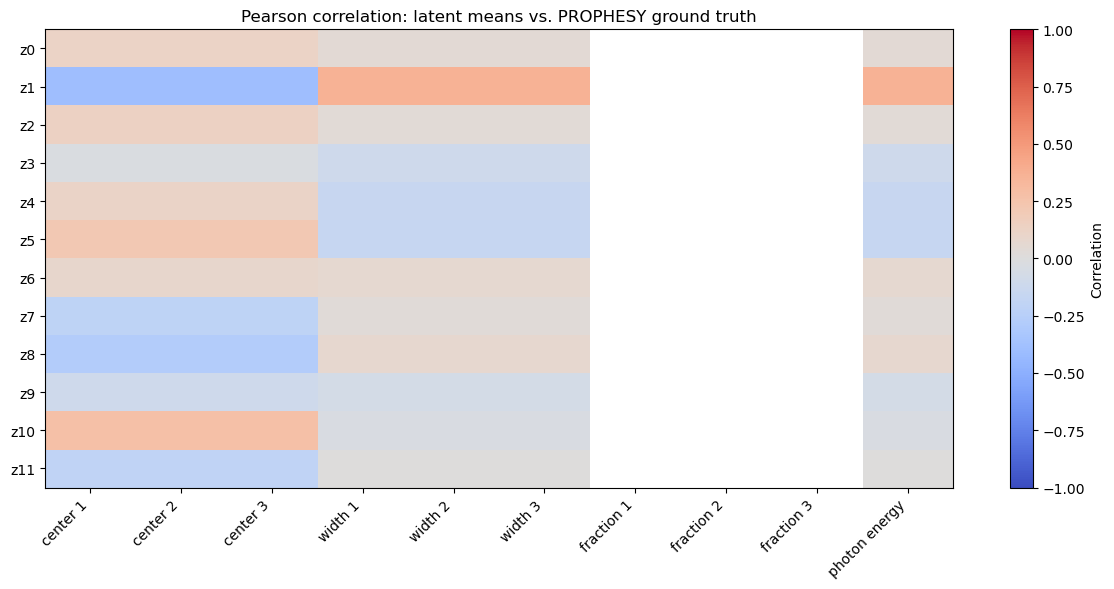

      center 1: z1 (r=-0.398)
      center 2: z1 (r=-0.398)
      center 3: z1 (r=-0.398)
       width 1: z1 (r=+0.360)
       width 2: z1 (r=+0.360)
       width 3: z1 (r=+0.360)
 photon energy: z1 (r=+0.360)


In [10]:
@torch.no_grad()
def encode_means(model, normalized_spectra, batch_size=1024):
    model.eval()
    result = []
    for start in range(0, len(normalized_spectra), batch_size):
        x = torch.from_numpy(normalized_spectra[start:start + batch_size]).to(DEVICE)
        mu, _ = model.encode(x)
        result.append(mu.cpu().numpy())
    return np.concatenate(result)

z_test = encode_means(model, x_all[test_idx])
physical = np.column_stack([
    dataset["peak_center"][test_idx],
    dataset["peak_width"][test_idx],
    dataset["peak_fraction"][test_idx],
    dataset["photon_energy"][test_idx],
])
physical_names = (
    [f"center {i + 1}" for i in range(3)]
    + [f"width {i + 1}" for i in range(3)]
    + [f"fraction {i + 1}" for i in range(3)]
    + ["photon energy"]
)

correlation = np.empty((z_test.shape[1], physical.shape[1]), dtype=np.float64)
for i in range(z_test.shape[1]):
    for j in range(physical.shape[1]):
        if np.std(z_test[:, i]) == 0 or np.std(physical[:, j]) == 0:
            correlation[i, j] = np.nan
        else:
            correlation[i, j] = np.corrcoef(z_test[:, i], physical[:, j])[0, 1]

fig, ax = plt.subplots(figsize=(12, 6))
image = ax.imshow(correlation, vmin=-1, vmax=1, cmap="coolwarm", aspect="auto")
ax.set_xticks(np.arange(len(physical_names)), physical_names, rotation=45, ha="right")
ax.set_yticks(np.arange(12), [f"z{i}" for i in range(12)])
ax.set_title("Pearson correlation: latent means vs. PROPHESY ground truth")
fig.colorbar(image, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

for j, name in enumerate(physical_names):
    valid = np.flatnonzero(np.isfinite(correlation[:, j]))
    if len(valid):
        best = valid[np.argmax(np.abs(correlation[valid, j]))]
        print(f"{name:>14}: z{best} (r={correlation[best, j]:+.3f})")

## Generate artificial spectra from the prior

These are unconditional samples from `z ~ N(0, I)`. Realistic reconstructions do not guarantee realistic prior samples, so compare their peak distributions and count statistics with held-out PROPHESY data before using them as a synthetic dataset.

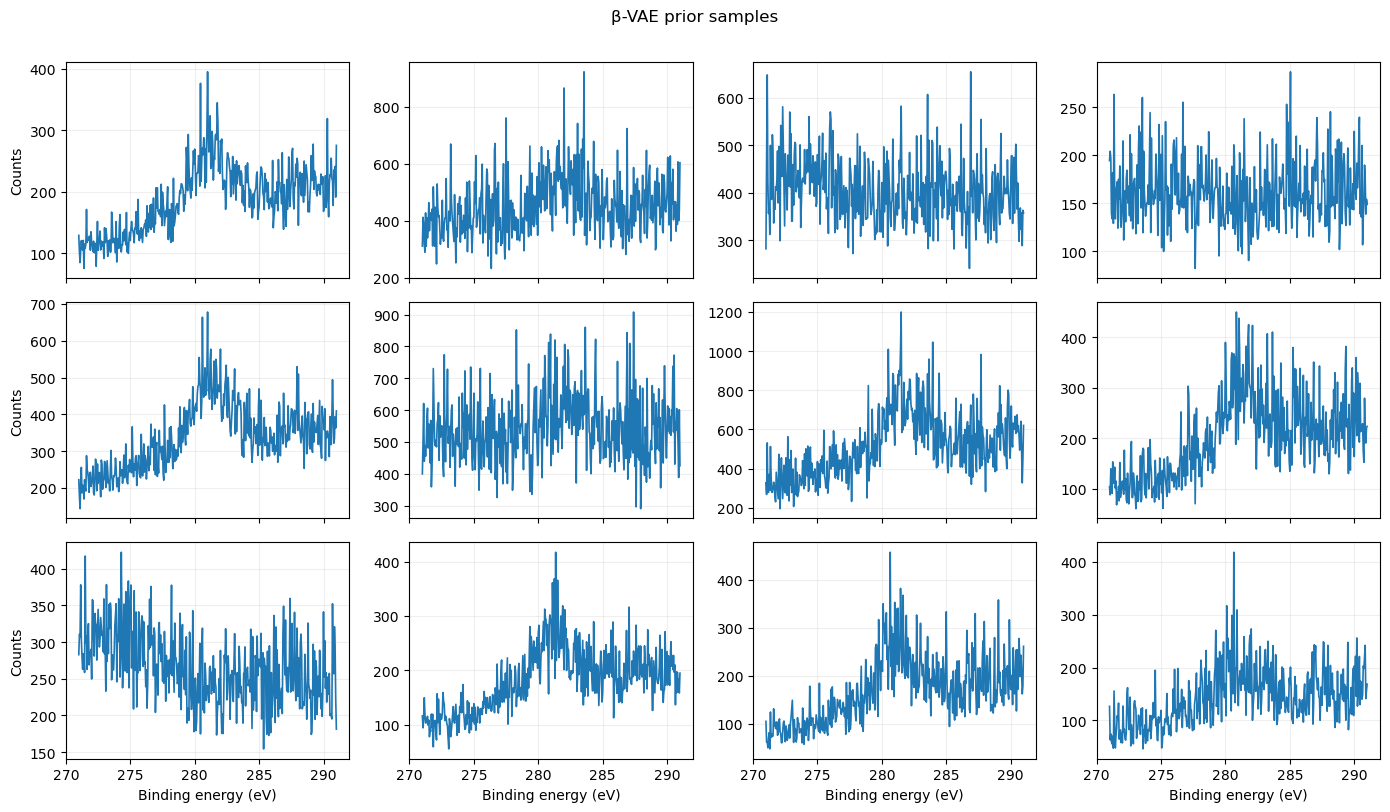

In [11]:
N_GENERATED = 12
with torch.no_grad():
    z = torch.randn(N_GENERATED, 12, device=DEVICE)
    generated_normalized = model.decode(z).cpu().numpy()
generated_counts = denormalize_counts(generated_normalized)

fig, axes = plt.subplots(3, 4, figsize=(14, 8), sharex=True)
for ax, spectrum in zip(axes.flat, generated_counts):
    ax.plot(axis, spectrum, color="tab:blue", lw=1.2)
    ax.grid(alpha=0.2)
for ax in axes[-1]:
    ax.set_xlabel("Binding energy (eV)")
for ax in axes[:, 0]:
    ax.set_ylabel("Counts")
fig.suptitle("β-VAE prior samples", y=1.01)
plt.tight_layout()
plt.show()

## Interpretation and next checks

A successful first reproduction should show: (1) smooth reconstructions that retain the three simulated C1s components, (2) lower reconstruction error against the noise-free expected signal than against individual noise spikes, and (3) one or more latent variables strongly correlated with peak position, width, mixture fraction, photon energy, or intensity.

Before treating generated spectra as a scientific dataset, compare real and generated distributions of peak centre, width, separation, integrated intensity, background, residuals, and correlations between these quantities. The next model extension would add an explicit peak-parameter head or physics-informed peak decoder; that is intentionally excluded here so this notebook remains an unsupervised reproduction of the paper's main approach.